In [4]:
import json
import pandas as pd
from pandas import json_normalize
import numpy as np

In [5]:
# with open('../data/small_friends_info.json', 'r', encoding='utf-8') as file:
#     data = json.load(file)

# ids = list(data.keys())
# records = list(data.values())

# df = json_normalize(records, sep='_')
# df['user_id'] = ids
# df.set_index('user_id', inplace=True)

# df.to_csv('../data/small_friends_info.csv', encoding='utf-8', index=True)
# print('Saved to data/friends_info.csv')


In [6]:
dataset = pd.read_csv('../data/small_friends_info.csv', index_col='user_id')
dataset.head()

,basic_info_id,basic_info_first_name,basic_info_last_name,basic_info_domain,basic_info_is_closed,demographics_sex,demographics_birth_date,demographics_age,demographics_city,demographics_country,...,interests_activities,interests_interests,interests_music,interests_movies,interests_books,interests_games,metadata_data_retrieved,metadata_has_education,metadata_has_career,metadata_interests_count
user_id,,,,,,,,,,,,,,,,,,,,,
163823935,163823935,Владимир,Демченко,NaN,False,мужской,19.11,NaN,Подольск,Россия,...,NaN,NaN,NaN,NaN,NaN,NaN,2025-10-23T22:28:44.346899,True,False,0
91478379,91478379,Катя,Панкратьева,NaN,False,женский,7.3,NaN,Paris,Франция,...,NaN,NaN,NaN,NaN,NaN,NaN,2025-10-23T22:28:44.351597,False,False,0
230631594,230631594,Алексей,Епифанцев,NaN,False,мужской,18.4,NaN,Химки,Россия,...,NaN,NaN,NaN,NaN,NaN,NaN,2025-10-23T22:28:44.361165,False,False,0
185888968,185888968,Эльдар,Аймалетдинов,NaN,False,мужской,11.10,NaN,Москва,Россия,...,NaN,NaN,NaN,NaN,NaN,NaN,2025-10-23T22:28:44.346930,False,False,0
184572109,184572109,Таисия,Петрова,NaN,False,женский,29.4,NaN,Москва,Россия,...,NaN,NaN,NaN,NaN,NaN,NaN,2025-10-23T22:28:44.361096,False,False,0


In [7]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 150 entries, 163823935 to 584995001
Data columns (total 29 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   basic_info_id                          150 non-null    int64  
 1   basic_info_first_name                  150 non-null    object 
 2   basic_info_last_name                   150 non-null    object 
 3   basic_info_domain                      0 non-null      float64
 4   basic_info_is_closed                   150 non-null    bool   
 5   demographics_sex                       150 non-null    object 
 6   demographics_birth_date                129 non-null    object 
 7   demographics_age                       60 non-null     float64
 8   demographics_city                      102 non-null    object 
 9   demographics_country                   118 non-null    object 
 10  education_career_education_university  34 non-null     object 
 1

In [8]:
null_col = ['basic_info_domain', 'social_connections_skype', 'social_connections_facebook', 'social_connections_twitter', 'social_connections_instagram']
useless_col = ['basic_info_first_name', 'basic_info_last_name', 'basic_info_is_closed', 'demographics_birth_date', 'demographics_country', 'education_career_education_graduation',
               'education_career_career', 'education_career_universities', 'metadata_data_retrieved', 'metadata_has_education', 'metadata_has_career',
               'interests_activities', 'interests_interests', 'interests_music', 'interests_movies', 'interests_books', 'interests_games', 'metadata_interests_count', 'basic_info_id']

In [9]:
dataset = dataset.drop(columns=null_col)
dataset = dataset.drop(columns=useless_col)

In [10]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 150 entries, 163823935 to 584995001
Data columns (total 5 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   demographics_sex                       150 non-null    object 
 1   demographics_age                       60 non-null     float64
 2   demographics_city                      102 non-null    object 
 3   education_career_education_university  34 non-null     object 
 4   education_career_education_faculty     20 non-null     object 
dtypes: float64(1), object(4)
memory usage: 7.0+ KB


<Axes: >

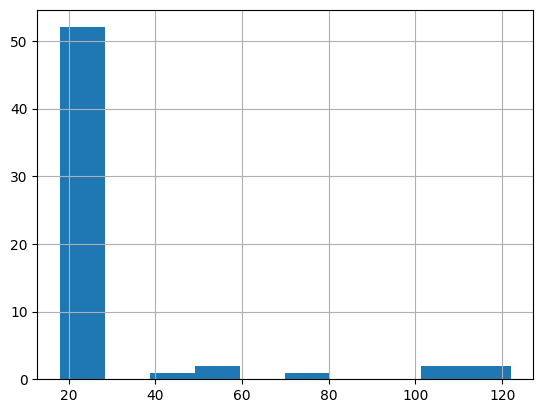

In [11]:
dataset['demographics_age'].hist()

In [12]:
dataset = dataset.loc[(dataset['demographics_age'] < 90) | (dataset['demographics_age'].isna())]

<Axes: >

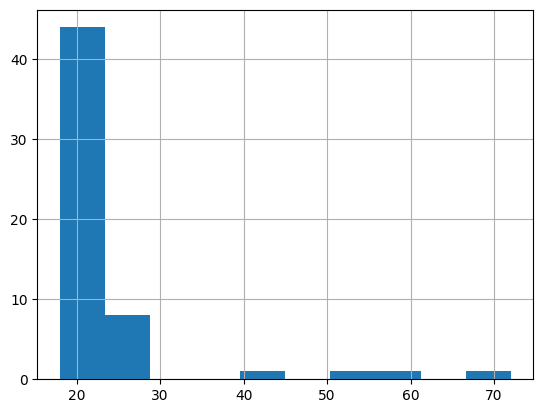

In [13]:
dataset['demographics_age'].hist()

In [14]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 146 entries, 163823935 to 584995001
Data columns (total 5 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   demographics_sex                       146 non-null    object 
 1   demographics_age                       56 non-null     float64
 2   demographics_city                      101 non-null    object 
 3   education_career_education_university  33 non-null     object 
 4   education_career_education_faculty     20 non-null     object 
dtypes: float64(1), object(4)
memory usage: 6.8+ KB


In [15]:
median_age = np.quantile(dataset['demographics_age'].dropna().values, q=0.5)

dataset['demographics_age'] = dataset['demographics_age'].fillna(median_age)

In [16]:
dataset['demographics_city'] = dataset['demographics_city'].fillna('Москва')
dataset['education_career_education_faculty'] = dataset['education_career_education_faculty'].fillna('Неизвестно')
dataset['education_career_education_university'] = dataset['education_career_education_university'].fillna('Неизвестно')

In [17]:
dataset['education_career_education_faculty'].value_counts()

education_career_education_faculty
Неизвестно                                                                  126
Институт информационных технологий                                           14
Институт высоких технологий                                                   1
Факультет информационных технологий                                           1
Институт кибербезопасности и цифровых технологий                              1
Факультет химико-фармацевтических технологий и биомедицинских препаратов      1
Философский                                                                   1
Факультет бизнеса «Капитаны»                                                  1
Name: count, dtype: int64

In [18]:
dataset['education_career_education_university'].value_counts()

education_career_education_university
Неизвестно                                     113
РТУ МИРЭА                                       23
МГТУ им. Н. Э. Баумана (бывш. МВТУ)              2
РХТУ им. Д. И. Менделеева                        2
МГУПИ                                            1
МГИМО МИД России                                 1
МИРЭА (до 2015)                                  1
МГУ                                              1
Президентская академия (РАНХиГС, бывш. АНХ)      1
РЭУ им. Г. В. Плеханова                          1
Name: count, dtype: int64

In [19]:
dataset['demographics_city'].value_counts()

demographics_city
Москва              107
Химки                10
Пенза                 3
Санкт-Петербург       3
Подольск              2
Одинцово              2
Минск                 1
Воронеж               1
Кизнер (поселок)      1
Бердск                1
Королёв               1
Berlin                1
Рязань                1
Евпатория             1
Таганрог              1
Бронницы              1
Fukuoka               1
Paris                 1
Ōfunato               1
Старый Оскол          1
Toronto               1
Жуковский             1
Барнаул               1
Качалино              1
Симферополь           1
Name: count, dtype: int64

In [20]:
dataset['demographics_sex'].value_counts()

demographics_sex
мужской    112
женский     34
Name: count, dtype: int64

In [21]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 146 entries, 163823935 to 584995001
Data columns (total 5 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   demographics_sex                       146 non-null    object 
 1   demographics_age                       146 non-null    float64
 2   demographics_city                      146 non-null    object 
 3   education_career_education_university  146 non-null    object 
 4   education_career_education_faculty     146 non-null    object 
dtypes: float64(1), object(4)
memory usage: 6.8+ KB


In [ ]:
# ...existing code...
import os, json, random
import pandas as pd

random.seed(42)
# пути (при необходимости поправьте)
features_path = '../data/friends_features.csv'
map_path = os.path.join('..', 'data', 'small_friends_map.json')
if not os.path.exists(map_path):
    map_path = os.path.join('data', 'small_friends_map.json')  # fallback

# загрузка
df_feat = pd.read_csv(features_path, index_col='user_id')
with open(map_path, 'r', encoding='utf-8') as f:
    friends_map = json.load(f)  # keys могут быть строками

# положительные пары
rows = []
for u_str, friends in friends_map.items():
    try:
        u = int(u_str)
    except:
        continue
    for fr in friends:
        rows.append({'user_id': u, 'friend_id': int(fr), 'is_friend': 1})

# опционально: добавить негативные примеры (не-друзья)
all_users = set(map(int, df_feat.index))
neg_per_user = 3
for u in list(all_users):
    friends_set = set(map(int, friends_map.get(str(u), [])))
    candidates = list(all_users - friends_set - {u})
    if not candidates:
        continue
    sampled = random.sample(candidates, min(neg_per_user, len(candidates)))
    for nf in sampled:
        rows.append({'user_id': u, 'friend_id': int(nf), 'is_friend': 0})

df_pairs = pd.DataFrame(rows)

# функция числа общих друзей
def common_friends_count(u, v):
    f1 = set(map(int, friends_map.get(str(u), [])))
    f2 = set(map(int, friends_map.get(str(v), [])))
    return len(f1 & f2)

df_pairs['common_friends_count'] = df_pairs.apply(lambda r: common_friends_count(r['user_id'], r['friend_id']), axis=1)

# присоединяем признаки user и friend
df_pairs = df_pairs.merge(df_feat.add_suffix('_user'), how='left', left_on='user_id', right_index=True)
df_pairs = df_pairs.merge(df_feat.add_suffix('_friend'), how='left', left_on='friend_id', right_index=True)

# сохранить
df_pairs.to_csv('../data/friends_features.csv', index=False)
print('Saved friends_features.csv, rows:', len(df_pairs))
# ...existing code...

C:\Users\q\AppData\Local\Temp\ipykernel_2520\2528968044.py:16: DtypeWarning: Columns (5,18) have mixed types. Specify dtype option on import or set low_memory=False.
  df_feat = pd.read_csv(features_path, index_col='user_id')
Подсчёт общих друзей: 100%|██████████| 1150/1150 [00:00<00:00, 112455.69it/s]


KeyboardInterrupt: 

In [ ]:
dataset = pd.read_csv('../data/friends_features.csv', encoding='utf-8', index_col='user_id')
dataset = dataset.dropna()
# dataset['is_friend'] = dataset['is_friend'].astype(bool)
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1212 entries, 258814756 to 466579963
Data columns (total 13 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   friend_id                                     1212 non-null   int64  
 1   is_friend                                     1212 non-null   bool   
 2   common_friends_count                          1212 non-null   int64  
 3   demographics_sex_user                         1212 non-null   object 
 4   demographics_age_user                         1212 non-null   float64
 5   demographics_city_user                        1212 non-null   object 
 6   education_career_education_university_user    1212 non-null   object 
 7   education_career_education_faculty_user       1212 non-null   object 
 8   demographics_sex_friend                       1212 non-null   object 
 9   demographics_age_friend                       1212 non-

In [ ]:
dataset.to_csv('../data/friends_features.csv', encoding='utf-8')